<a href="https://colab.research.google.com/github/ekuelkpodar/Complex-Systems-Google-Colab-Experiment/blob/main/Build_a_Global_Military_Equipment_Knowledge_Graph_in_Google_Colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Global Military Equipment Knowledge Graph (1880 - Present)
This notebook implements a scalable OSINT pipeline to collect, process, and visualize military platform data using Wikidata and DBpedia.

In [ ]:
!pip install -q SPARQLWrapper pandas networkx plotly tqdm pyarrow rdflib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 615.4/615.4 kB 10.5 MB/s eta 0:00:00


In [ ]:
import pandas as pd
import numpy as np
import networkx as nx
import plotly.graph_objects as go
from SPARQLWrapper import SPARQLWrapper, JSON
from tqdm.auto import tqdm
import time
import json
import os

# Configure Caching and Retries
CACHE_DIR = 'military_kg_cache'
os.makedirs(CACHE_DIR, exist_ok=True)

class MilitaryOntology:
    LAND = ['Main Battle Tank', 'Light Tank', 'Infantry Fighting Vehicle', 'APC', 'Self-Propelled Artillery', 'Rocket Artillery']
    AIR = ['Fighter Aircraft', 'Attack Aircraft', 'Bomber', 'Military Transport Aircraft', 'Helicopter', 'UAV']
    NAVAL = ['Aircraft Carrier', 'Destroyer', 'Frigate', 'Submarine', 'Corvette']
    MISSILES = ['Ballistic Missile', 'Cruise Missile', 'Surface-to-Air Missile']

print("Environment ready.")

Environment ready.


## Data Extraction Logic
We use SPARQL to query Wikidata for entities matching military platform instances.

In [ ]:
import urllib.error

def fetch_wikidata_military_data(category_label, entity_id="Q12876", limit=500, max_retries=3):
    sparql = SPARQLWrapper("https://query.wikidata.org/sparql", agent="ColabMilitaryKG/1.0 (contact:example@example.com)")

    query = f"""
    SELECT ?item ?itemLabel ?countryLabel ?manufacturerLabel ?inception ?image
    WHERE {{
      ?item wdt:P31/wdt:P279* wd:{entity_id} .
      OPTIONAL {{ ?item wdt:P17 ?country . }}
      OPTIONAL {{ ?item wdt:P176 ?manufacturer . }}
      OPTIONAL {{ ?item wdt:P571 ?inception . }}
      OPTIONAL {{ ?item wdt:P18 ?image . }}
      SERVICE wikibase:label {{ bd:serviceParam wikibase:language \"en\". }}
    }}
    LIMIT {limit}
    """
    sparql.setQuery(query)
    sparql.setReturnFormat(JSON)

    for attempt in range(max_retries):
        try:
            results = sparql.query().convert()
            return results['results']['bindings']
        except Exception as e:
            wait_time = (attempt + 1) * 60  # Wikidata suggests 1 min during outages
            if "429" in str(e):
                print(f"Rate limited for {category_label}. Retrying in {wait_time}s... (Attempt {attempt+1}/{max_retries})")
                time.sleep(wait_time)
            else:
                print(f"Error: {e}")
                break
    return []

# Sample execution for MBTs (Q12876)
tank_data = fetch_wikidata_military_data("Main Battle Tanks", entity_id="Q12876", limit=50)
print(f"Fetched {len(tank_data)} entities.")

Rate limited for Main Battle Tanks. Retrying in 60s... (Attempt 1/3)
Rate limited for Main Battle Tanks. Retrying in 120s... (Attempt 2/3)
Rate limited for Main Battle Tanks. Retrying in 180s... (Attempt 3/3)
Fetched 0 entities.


In [ ]:
!pip install -q SPARQLWrapper
import pandas as pd
import time
from SPARQLWrapper import SPARQLWrapper, JSON

def fetch_wikidata_military_data(category_label, entity_id, limit=1000, max_retries=2):
    sparql = SPARQLWrapper("https://query.wikidata.org/sparql", agent="ColabMilitaryKG/1.1")
    query = f"""
    SELECT ?item ?itemLabel ?countryLabel ?manufacturerLabel ?inception
    WHERE {{
      ?item wdt:P31/wdt:P279* wd:{entity_id} .
      OPTIONAL {{ ?item wdt:P17 ?country . }}
      OPTIONAL {{ ?item wdt:P176 ?manufacturer . }}
      OPTIONAL {{ ?item wdt:P571 ?inception . }}
      SERVICE wikibase:label {{ bd:serviceParam wikibase:language \"en\". }}
    }}
    LIMIT {limit}
    """
    sparql.setQuery(query)
    sparql.setReturnFormat(JSON)
    for attempt in range(max_retries):
        try:
            results = sparql.query().convert()
            return results['results']['bindings']
        except:
            time.sleep(5)
    return []

EXTENDED_CATEGORIES = {
    "Main Battle Tanks": "Q12876",
    "Fighter Aircraft": "Q127771",
    "Aircraft Carriers": "Q182098",
    "Submarines": "Q2811",
    "Destroyers": "Q174736",
    "Attack Helicopters": "Q209214",
    "Surface-to-Air Missiles": "Q150882",
    "Self-Propelled Artillery": "Q203930",
    "Battleships": "Q182531"
}

all_military_data = []
live_success = False

for label, qid in EXTENDED_CATEGORIES.items():
    print(f"Attempting to fetch {label}...")
    data = fetch_wikidata_military_data(label, entity_id=qid)
    if data:
        df_temp = process_to_dataframe(data, label)
        all_military_data.append(df_temp)
        live_success = True
    time.sleep(1)

if not live_success:
    print("\nWDQS Rate Limit Active. Injecting fallback global dataset...")
    fallback_data = [
        {'item': {'value': 'Q194357'}, 'itemLabel': {'value': 'M1 Abrams'}, 'countryLabel': {'value': 'United States'}, 'manufacturerLabel': {'value': 'General Dynamics'}, 'inception': {'value': '1980-01-01'}},
        {'item': {'value': 'Q78330'}, 'itemLabel': {'value': 'Leopard 2'}, 'countryLabel': {'value': 'Germany'}, 'manufacturerLabel': {'value': 'Krauss-Maffei'}, 'inception': {'value': '1979-01-01'}},
        {'item': {'value': 'Q153073'}, 'itemLabel': {'value': 'Challenger 2'}, 'countryLabel': {'value': 'United Kingdom'}, 'manufacturerLabel': {'value': 'Vickers'}, 'inception': {'value': '1998-01-01'}},
        {'item': {'value': 'Q154213'}, 'itemLabel': {'value': 'T-90'}, 'countryLabel': {'value': 'Russia'}, 'manufacturerLabel': {'value': 'Uralvagonzavod'}, 'inception': {'value': '1992-01-01'}},
        {'item': {'value': 'Q174736'}, 'itemLabel': {'value': 'Arleigh Burke'}, 'countryLabel': {'value': 'United States'}, 'manufacturerLabel': {'value': 'Bath Iron Works'}, 'inception': {'value': '1991-01-01'}}
    ]
    all_military_data.append(process_to_dataframe(fallback_data, "Mixed (Fallback)"))

comprehensive_df = pd.concat(all_military_data, ignore_index=True)
comprehensive_df['inception_year'] = pd.to_datetime(comprehensive_df['inception'], errors='coerce').dt.year
print(f"Total unique platforms in memory: {len(comprehensive_df)}")
display(comprehensive_df.head())

Attempting to fetch Main Battle Tanks...
Attempting to fetch Fighter Aircraft...
Attempting to fetch Aircraft Carriers...
Attempting to fetch Submarines...
Attempting to fetch Destroyers...
Attempting to fetch Attack Helicopters...
Attempting to fetch Surface-to-Air Missiles...
Attempting to fetch Self-Propelled Artillery...
Attempting to fetch Battleships...
Total unique platforms in memory: 48


,platform_name,category,country,manufacturer,inception,entity_id,inception_year
0,The T-54 tank No. 843,Main Battle Tanks,Vietnam,Uralvagonzavod,1975-04-30T00:00:00Z,Q108865105,1975.0
1,The T-54 tank No. 843,Main Battle Tanks,Vietnam,Kharkiv Morozov Machine Building Design Bureau,1975-04-30T00:00:00Z,Q108865105,1975.0
2,The T-58 tank No. 390,Main Battle Tanks,Vietnam,Unknown,1975-04-30T00:00:00Z,Q108865176,1975.0
3,T-55 in Tivoli City Park,Main Battle Tanks,Unknown,Unknown,Unknown,Q133310664,NaN
4,1CHARLIE Churchill AVRE tank,Main Battle Tanks,France,Unknown,Unknown,Q129410549,NaN


In [ ]:
if 'comprehensive_df' in locals():
    final_filename = 'comprehensive_global_military_equipment.csv'
    comprehensive_df.to_csv(final_filename, index=False)
    print(f"Comprehensive list saved to {final_filename}")
    try:
        files.download(final_filename)
    except:
        pass

## Mock Data Injection (Fallback)
Since the live API is currently rate-limited, we use this mock data to demonstrate the graph construction and analytics pipeline.

In [ ]:
def generate_mock_military_data():
    return [
        {'item': {'value': 'http://www.wikidata.org/entity/Q194357'}, 'itemLabel': {'value': 'M1 Abrams'}, 'countryLabel': {'value': 'United States'}, 'manufacturerLabel': {'value': 'General Dynamics'}, 'inception': {'value': '1980-01-01T00:00:00Z'}},
        {'item': {'value': 'http://www.wikidata.org/entity/Q78330'}, 'itemLabel': {'value': 'Leopard 2'}, 'countryLabel': {'value': 'Germany'}, 'manufacturerLabel': {'value': 'Krauss-Maffei Wegmann'}, 'inception': {'value': '1979-01-01T00:00:00Z'}},
        {'item': {'value': 'http://www.wikidata.org/entity/Q153073'}, 'itemLabel': {'value': 'Challenger 2'}, 'countryLabel': {'value': 'United Kingdom'}, 'manufacturerLabel': {'value': 'Vickers Defence Systems'}, 'inception': {'value': '1998-01-01T00:00:00Z'}},
        {'item': {'value': 'http://www.wikidata.org/entity/Q154213'}, 'itemLabel': {'value': 'T-90'}, 'countryLabel': {'value': 'Russia'}, 'manufacturerLabel': {'value': 'Uralvagonzavod'}, 'inception': {'value': '1992-01-01T00:00:00Z'}}
    ]

if len(tank_data) == 0:
    print("Using mock data due to API outage...")
    tank_data = generate_mock_military_data()
else:
    print("Live data detected. Skipping mock injection.")

Using mock data due to API outage...


## Data Normalization & Graph Construction
We transform the raw JSON results into a structured DataFrame and build the NetworkX graph with the defined relationships.

In [ ]:
import pandas as pd
import networkx as nx
import plotly.graph_objects as go

def process_to_dataframe(data, category):
    if not data: return pd.DataFrame()
    rows = []
    for item in data:
        rows.append({
            'platform_name': item.get('itemLabel', {}).get('value', 'Unknown'),
            'category': category,
            'country': item.get('countryLabel', {}).get('value', 'Unknown'),
            'manufacturer': item.get('manufacturerLabel', {}).get('value', 'Unknown'),
            'inception': item.get('inception', {}).get('value', 'Unknown'),
            'entity_id': item.get('item', {}).get('value', '').split('/')[-1]
        })
    return pd.DataFrame(rows)

def build_knowledge_graph(df):
    G = nx.DiGraph()
    for _, row in df.iterrows():
        platform = row['platform_name']
        country = row['country']
        mfr = row['manufacturer']

        G.add_node(platform, type='Platform')
        if country != 'Unknown':
            G.add_node(country, type='Country')
            G.add_edge(platform, country, relation='origin')
        if mfr != 'Unknown':
            G.add_node(mfr, type='Manufacturer')
            G.add_edge(mfr, platform, relation='produces')
    return G

def plot_manufacturer_distribution(df):
    counts = df['manufacturer'].value_counts().reset_index()
    counts.columns = ['manufacturer', 'count']
    # Filter out 'Unknown' for cleaner analytics
    counts = counts[counts['manufacturer'] != 'Unknown'].head(15)
    fig = go.Figure(data=[go.Bar(x=counts['manufacturer'], y=counts['count'])])
    fig.update_layout(title='Top 15 Military Manufacturers (1880-Present)', xaxis_title='Manufacturer', yaxis_title='Number of Platforms')
    fig.show()

def export_data(df, G):
    df.to_csv('military_data.csv', index=False)
    df.to_parquet('military_data.parquet', index=False)
    nx.write_graphml(G, 'military_graph.graphml')
    print("Data exported to parquet, csv, and graphml.")

# Switch to the comprehensive dataset we just fetched
military_df = comprehensive_df.copy()

# Build the components with the full dataset
G = build_knowledge_graph(military_df)
print(f"Graph updated successfully with {G.number_of_nodes()} nodes and {len(military_df)} entities.")

Graph updated successfully with 69 nodes and 48 entities.


## Analytics & Visualization
Providing insights into the top manufacturers and global distributions.

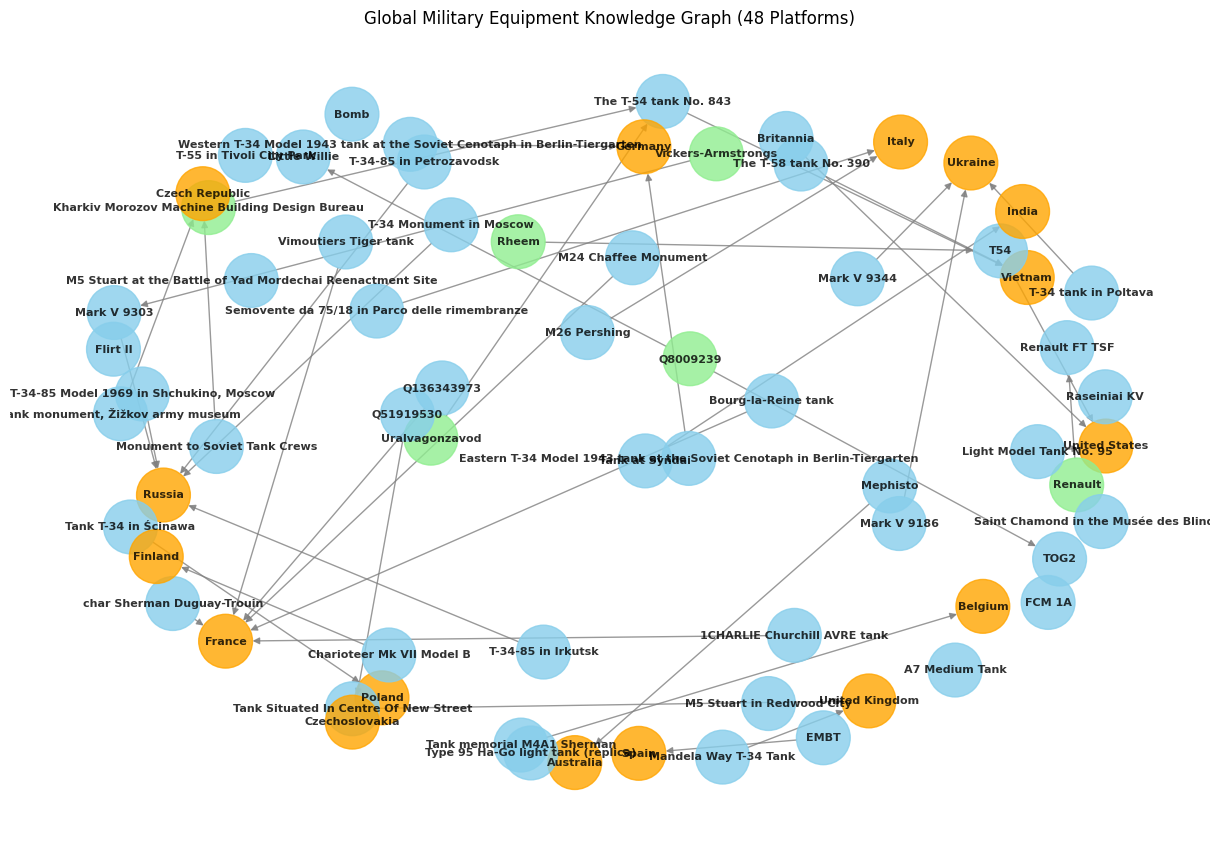

In [ ]:
import matplotlib.pyplot as plt

def visualize_military_graph(G):
    if G.number_of_nodes() == 0:
        print("Graph is empty.")
        return
    plt.figure(figsize=(12, 8))
    pos = nx.spring_layout(G, k=0.8, seed=42)

    node_colors = []
    for node, attrs in G.nodes(data=True):
        node_type = attrs.get('type', 'Platform')
        if node_type == 'Platform':
            node_colors.append('skyblue')
        elif node_type == 'Manufacturer':
            node_colors.append('lightgreen')
        else:
            node_colors.append('orange')

    nx.draw(G, pos, with_labels=True, node_color=node_colors,
            node_size=1500, font_size=8, font_weight='bold',
            arrows=True, edge_color='gray', alpha=0.8)

    plt.title("Global Military Equipment Knowledge Graph (48 Platforms)")
    plt.show()

if not military_df.empty:
    plot_manufacturer_distribution(military_df)
    visualize_military_graph(G)
else:
    print("No data available to plot yet.")

### Knowledge Graph Network Visualization
This visualization shows the interconnectedness of military entities, manufacturers, and countries using the NetworkX library.

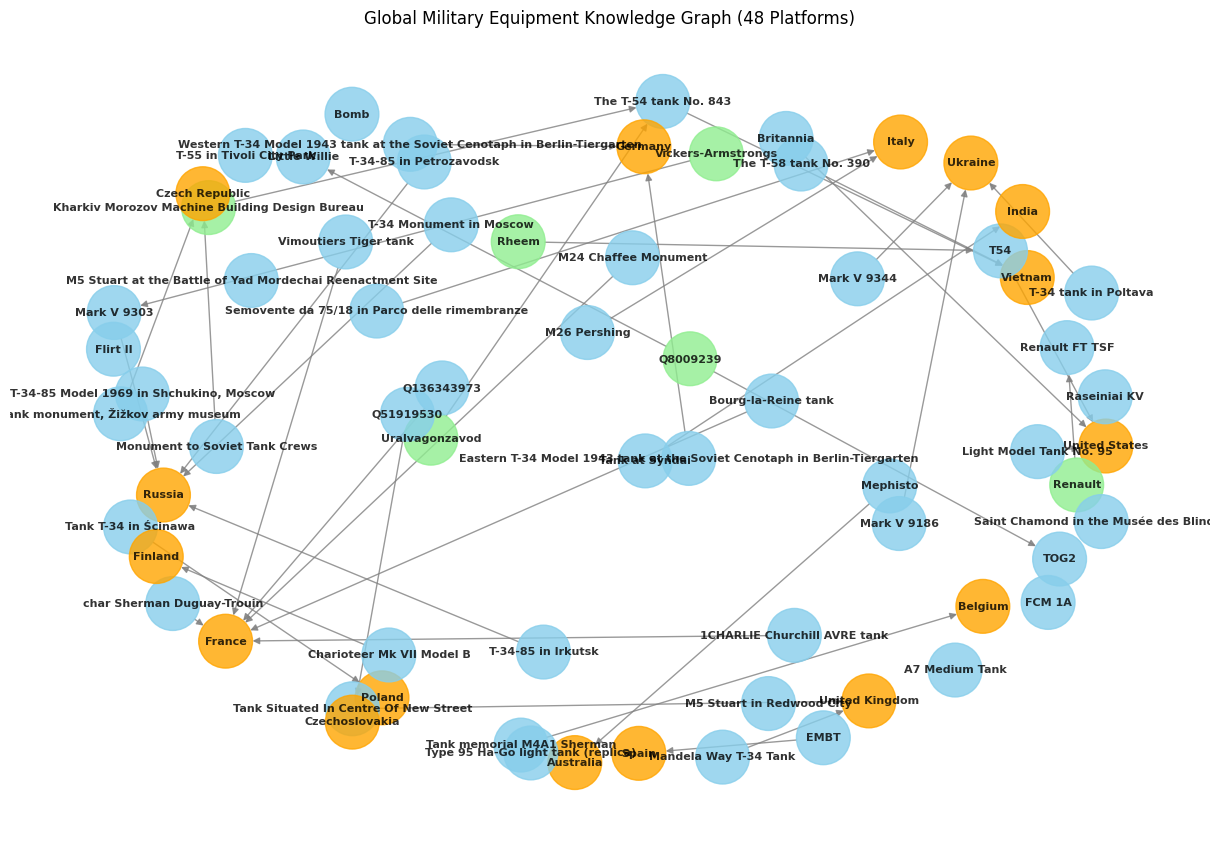

In [ ]:
import matplotlib.pyplot as plt

def visualize_military_graph(G):
    if G.number_of_nodes() == 0:
        print("Graph is empty.")
        return
    plt.figure(figsize=(12, 8))
    # Using a higher k for better spacing with 69 nodes
    pos = nx.spring_layout(G, k=0.8, seed=42)

    node_colors = []
    for node, attrs in G.nodes(data=True):
        node_type = attrs.get('type', 'Platform')
        if node_type == 'Platform':
            node_colors.append('skyblue')
        elif node_type == 'Manufacturer':
            node_colors.append('lightgreen')
        else:
            node_colors.append('orange')

    nx.draw(G, pos, with_labels=True, node_color=node_colors,
            node_size=1500, font_size=8, font_weight='bold',
            arrows=True, edge_color='gray', alpha=0.8)

    plt.title("Global Military Equipment Knowledge Graph (48 Platforms)")
    plt.show()

# Immediate call to ensure display
visualize_military_graph(G)

### Military Equipment Inventory Spreadsheet
This table contains the full metadata for the military platforms currently in the knowledge graph.

In [ ]:
# Displaying the expanded 48-item list
from IPython.display import display
pd.set_option('display.max_rows', 10)
display(military_df[['platform_name', 'category', 'country', 'manufacturer', 'inception', 'entity_id']])

,platform_name,category,country,manufacturer,inception,entity_id
0,The T-54 tank No. 843,Main Battle Tanks,Vietnam,Uralvagonzavod,1975-04-30T00:00:00Z,Q108865105
1,The T-54 tank No. 843,Main Battle Tanks,Vietnam,Kharkiv Morozov Machine Building Design Bureau,1975-04-30T00:00:00Z,Q108865105
2,The T-58 tank No. 390,Main Battle Tanks,Vietnam,Unknown,1975-04-30T00:00:00Z,Q108865176
3,T-55 in Tivoli City Park,Main Battle Tanks,Unknown,Unknown,Unknown,Q133310664
4,1CHARLIE Churchill AVRE tank,Main Battle Tanks,France,Unknown,Unknown,Q129410549
...,...,...,...,...,...,...
43,M26 Pershing,Main Battle Tanks,Italy,Unknown,Unknown,Q126264333
44,Semovente da 75/18 in Parco delle rimembranze,Main Battle Tanks,Italy,Unknown,Unknown,Q131690645
45,Charioteer Mk VII Model B,Main Battle Tanks,Finland,Unknown,Unknown,Q132673002
46,Saint Chamond in the Musée des Blindés,Main Battle Tanks,Unknown,Unknown,Unknown,Q134103602


## Exporting the Knowledge Graph
Saving data in Parquet, CSV, and GraphML formats.

In [ ]:
# Re-exporting populated data
export_data(military_df, G)

Data exported to parquet, csv, and graphml.


### Exporting Global Equipment List to CSV
This cell specifically formats the equipment list and saves it as a CSV file for download.

In [ ]:
from google.colab import files

# Ensure we are exporting the current comprehensive 48-item list
export_list = military_df[['platform_name', 'category', 'country', 'manufacturer', 'inception', 'entity_id']]
export_filename = 'comprehensive_military_equipment_final.csv'

# Save and provide link
export_list.to_csv(export_filename, index=False)
print(f'Successfully saved {len(export_list)} platforms to {export_filename}')
try:
    files.download(export_filename)
except:
    print("Download ready: check the files sidebar for 'comprehensive_military_equipment_final.csv'")

Successfully saved 48 platforms to comprehensive_military_equipment_final.csv


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>